# AHO best ligand to ferrocene ligand Euclidean distance showcase

Use the AHO asymmetric hydrogenation dataset to test whether CatEmb Euclidean-distance similarity from a high-ee, non-ferrocene best ligand can identify high-ee ferrocene-containing ligands for the same substrate and metal. Smaller distance means higher similarity.

Filtering strategy:

- Substrate: `COC(=O)/C(=C/c1ccccc1)NC(C)=O`
- Metal: `Rh`
- Seed ligands: best ligand for each substrate-metal pair
- Candidate ligands: ligands containing Fe atom in the ligand SMILES


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from rdkit import Chem

ROOT = Path.cwd().resolve()
if ROOT.name == "notebook":
    NOTEBOOK_DIR = ROOT
    REPO_ROOT = ROOT.parent
else:
    REPO_ROOT = ROOT
    NOTEBOOK_DIR = REPO_ROOT / "notebook"

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from catemb import CatEmb

DATA_PATH = REPO_ROOT / "dataset" / "rxn_data" / "aho_dataset_with_productivity.csv"
DESC_PATH = NOTEBOOK_DIR / "gen_desc" / "aho_rh_ligand_catemb.npy"
OUTPUT_DIR = NOTEBOOK_DIR / "recommend_results" / "aho_single_p_to_ferrocene_showcase"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REACTANT_SMILES = "COC(=O)/C(=C/c1ccccc1)NC(C)=O"
METAL = "Rh"
HIGH_EE_THRESHOLD = 0.90
TOP_N = 5

pd.set_option("display.max_colwidth", 140)


/opt/conda/envs/catemb/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def has_element(smiles, symbol):
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None and any(atom.GetSymbol() == symbol for atom in mol.GetAtoms())

raw_df = pd.read_csv(DATA_PATH, index_col=0)
rxn_df = raw_df[raw_df["Reactant SMILES"].eq(REACTANT_SMILES) & raw_df["Metal"].eq(METAL)].copy()
rxn_df["has_fe"] = rxn_df["Ligand SMILES"].apply(lambda smi: has_element(smi, "Fe"))

ligand_df = (
    rxn_df.groupby("Ligand SMILES")
    .agg(
        avg_ee=("ee", "mean"),
        max_ee=("ee", "max"),
        n_reactions=("ee", "size"),
        has_high_ee=("ee", lambda x: bool((x > HIGH_EE_THRESHOLD).any())),
        scaffold_type=("Scaffold type", "first"),
        multi_scaffold_type=("Multi-scaffold type", "first"),
        has_fe=("has_fe", "first"),
    )
    .reset_index()
)
best_lig_df = ligand_df.sort_values(by="avg_ee", ascending=False)[:1]
display(best_lig_df)

candidate_pool = ligand_df[ligand_df["has_fe"]].copy().reset_index(drop=True)

print(f"Filtered reactions: {len(rxn_df)}")
print(f"Unique ligands: {len(ligand_df)}")
print(f"Fe-containing candidate ligands: {len(candidate_pool)}")


,Ligand SMILES,avg_ee,max_ee,n_reactions,has_high_ee,scaffold_type,multi_scaffold_type,has_fe
203,Fc1c(F)c(F)c(COc2ccccc2P(CCP(c2ccccc2)c2ccccc2OCc2c(F)c(F)c(F)c(F)c2F)c2ccccc2)c(F)c1F,1.0,1.0,1,True,double P type,['double P type'],False


Filtered reactions: 548
Unique ligands: 268
Fe-containing candidate ligands: 52


In [3]:
unique_ligands = ligand_df["Ligand SMILES"].tolist()

need_regen = True
if DESC_PATH.exists():
    cache = np.load(DESC_PATH, allow_pickle=True).item()
    if set(unique_ligands).issubset(set(cache["smi"])):
        need_regen = False

if need_regen:
    catemb_calc = CatEmb(device="cpu")
    cache = {"smi": unique_ligands, "desc": catemb_calc.gen_desc(unique_ligands, batch_size=64)}
    np.save(DESC_PATH, cache)

desc_map = {smi: np.asarray(desc) for smi, desc in zip(cache["smi"], cache["desc"])}
print(f"CatEmb cache: {DESC_PATH}")
print(f"CatEmb dimension: {len(next(iter(desc_map.values())))}")


CatEmb cache: /inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/8359-xulicheng/CatEmb/GitHub/CatEmb/notebook/gen_desc/aho_rh_ligand_catemb.npy
CatEmb dimension: 32


In [4]:
def euclidean_distance_to_pool(seed_smiles, pool_smiles):
    seed_vec = desc_map[seed_smiles].reshape(1, -1)
    pool_vec = np.stack([desc_map[smi] for smi in pool_smiles], axis=0)
    return np.linalg.norm(pool_vec - seed_vec, axis=1)

ranked_by_seed = {}
seed_scores = []
for _, seed in best_lig_df.iterrows():
    distances = euclidean_distance_to_pool(seed["Ligand SMILES"], candidate_pool["Ligand SMILES"].tolist())
    ranked = candidate_pool.assign(euclidean_distance=distances).sort_values("euclidean_distance", ascending=True).reset_index(drop=True)
    ranked_by_seed[seed["Ligand SMILES"]] = ranked


#seed_smiles = seed_scores_df.loc[1, "seed_smiles"]      ## ####### 1 is good
seed_smiles = best_lig_df['Ligand SMILES'].to_list()[0]
ranked_df = ranked_by_seed[seed_smiles].copy()
ranked_df.insert(0, "similarity_rank", np.arange(1, len(ranked_df) + 1))

display(ranked_df)
print(f"Selected seed ligand: {seed_smiles}")


,similarity_rank,Ligand SMILES,avg_ee,max_ee,n_reactions,has_high_ee,scaffold_type,multi_scaffold_type,has_fe,euclidean_distance
0,1,C[C@@H](C1=C[C@H]([Fe]C2C=CC=C2)C=C1P(c1ccccc1)c1ccccc1)n1nnc(-c2ccccc2F)c1P(c1ccccc1)c1ccccc1,0.980000,0.98,1,True,ferrocene type,"['ferrocene type', 'double P type']",True,1.293273
1,2,C[C@H](C1=C(P(c2ccccc2)c2ccccc2)C=C[C@@H]1[Fe]C1C=CC=C1)N(C)P(c1ccc(Cl)c(Cl)c1)c1ccc(Cl)c(Cl)c1,0.990000,0.99,1,True,ferrocene type,"['ferrocene type', 'double P type']",True,1.296583
2,3,C[C@H](C1=C(P(c2ccccc2)c2ccccc2)C=C[C@@H]1[Fe]C1C=CC=C1)N(C)P(c1cc(Cl)cc(Cl)c1)c1cc(Cl)cc(Cl)c1,0.990000,0.99,1,True,ferrocene type,"['ferrocene type', 'double P type']",True,1.305690
3,4,C[C@H](C1=C(P(c2ccccc2)c2ccccc2)C=C[C@@H]1[Fe]C1C=CC=C1)N(C)P(c1ccc(F)c(F)c1)c1ccc(F)c(F)c1,0.990000,0.99,1,True,ferrocene type,"['ferrocene type', 'double P type']",True,1.307044
4,5,C[C@H](C1=C(P(c2ccccc2)c2ccccc2)C=C[C@@H]1[Fe]C1C=CC=C1)N(C)P(c1cc(F)cc(F)c1)c1cc(F)cc(F)c1,0.990000,0.99,1,True,ferrocene type,"['ferrocene type', 'double P type']",True,1.346155
5,6,C[C@H](C1=C(P(c2ccccc2)c2ccccc2)C=C[C@@H]1[Fe]C1C=CC=C1)N(C)P(c1cccc(F)c1)c1cccc(F)c1,0.990000,0.99,1,True,ferrocene type,"['ferrocene type', 'double P type']",True,1.361583
6,7,C[C@H](C1=C(P(c2ccccc2)c2ccccc2)C=C[C@@H]1[Fe]C1C=CC=C1)N(C)P(c1ccc(Cl)cc1)c1ccc(Cl)cc1,0.990000,0.99,1,True,ferrocene type,"['ferrocene type', 'double P type']",True,1.380697
7,8,C[C@H](C1=C(P(c2ccccc2)c2ccccc2)C=C[C@@H]1[Fe]C1C=CC=C1)N(C)P(c1ccc(F)cc1)c1ccc(F)cc1,0.990000,0.99,1,True,ferrocene type,"['ferrocene type', 'double P type']",True,1.401505
8,9,C[C@@H](C1=C[C@H]([Fe]C2C=CC=C2)C=C1P(c1ccccc1)c1ccccc1)n1nncc1P(c1ccccc1)c1ccccc1,0.930000,0.93,1,True,ferrocene type,"['ferrocene type', 'double P type']",True,1.511996
9,10,C[C@H](C1=C(P(c2ccccc2)c2ccccc2)C=C[C@@H]1[Fe]C1C=CC=C1)N(CC(C)(C)C)P(c1ccccc1)c1ccccc1,0.710000,0.71,1,False,ferrocene type,"['ferrocene type', 'double P type']",True,1.512670


Selected seed ligand: Fc1c(F)c(F)c(COc2ccccc2P(CCP(c2ccccc2)c2ccccc2OCc2c(F)c(F)c(F)c(F)c2F)c2ccccc2)c(F)c1F


In [5]:
top5_df = ranked_df.head(TOP_N).copy()
bottom5_df = ranked_df.tail(TOP_N).sort_values("euclidean_distance", ascending=False).copy()
showcase_df = pd.concat([top5_df.assign(group="top_similarity"), bottom5_df.assign(group="bottom_similarity")])
showcase_df = showcase_df[[
    "group",
    "similarity_rank",
    "euclidean_distance",
    "avg_ee",
    "max_ee",
    "n_reactions",
    "scaffold_type",
    "multi_scaffold_type",
    "Ligand SMILES",
]]



print("Top-5 and bottom-5 Fe-containing candidates ranked by CatEmb Euclidean distance")
display(showcase_df)

candidate_pool.to_csv(OUTPUT_DIR / "fe_candidate_pool.csv", index=False)
ranked_df.to_csv(OUTPUT_DIR / "ranked_fe_candidates.csv", index=False)
showcase_df.to_csv(OUTPUT_DIR / "top_bottom_fe_candidates.csv", index=False)


Top-5 and bottom-5 Fe-containing candidates ranked by CatEmb Euclidean distance


,group,similarity_rank,euclidean_distance,avg_ee,max_ee,n_reactions,scaffold_type,multi_scaffold_type,Ligand SMILES
0,top_similarity,1,1.293273,0.980,0.98,1,ferrocene type,"['ferrocene type', 'double P type']",C[C@@H](C1=C[C@H]([Fe]C2C=CC=C2)C=C1P(c1ccccc1)c1ccccc1)n1nnc(-c2ccccc2F)c1P(c1ccccc1)c1ccccc1
1,top_similarity,2,1.296583,0.990,0.99,1,ferrocene type,"['ferrocene type', 'double P type']",C[C@H](C1=C(P(c2ccccc2)c2ccccc2)C=C[C@@H]1[Fe]C1C=CC=C1)N(C)P(c1ccc(Cl)c(Cl)c1)c1ccc(Cl)c(Cl)c1
2,top_similarity,3,1.305690,0.990,0.99,1,ferrocene type,"['ferrocene type', 'double P type']",C[C@H](C1=C(P(c2ccccc2)c2ccccc2)C=C[C@@H]1[Fe]C1C=CC=C1)N(C)P(c1cc(Cl)cc(Cl)c1)c1cc(Cl)cc(Cl)c1
3,top_similarity,4,1.307044,0.990,0.99,1,ferrocene type,"['ferrocene type', 'double P type']",C[C@H](C1=C(P(c2ccccc2)c2ccccc2)C=C[C@@H]1[Fe]C1C=CC=C1)N(C)P(c1ccc(F)c(F)c1)c1ccc(F)c(F)c1
4,top_similarity,5,1.346155,0.990,0.99,1,ferrocene type,"['ferrocene type', 'double P type']",C[C@H](C1=C(P(c2ccccc2)c2ccccc2)C=C[C@@H]1[Fe]C1C=CC=C1)N(C)P(c1cc(F)cc(F)c1)c1cc(F)cc(F)c1
51,bottom_similarity,52,2.298947,0.950,0.95,1,ferrocene type,"['ferrocene type', 'double P type']",Cc1cc(C)cc(P(C2=C[C@@H]([Fe]C3C=CC=C3)C=C2[C@H](C)n2nnc(-c3ccccc3)c2P(c2cc(C)cc(C)c2)c2cc(C)cc(C)c2)c2cc(C)cc(C)c2)c1
50,bottom_similarity,51,2.165344,0.980,0.98,1,ferrocene type,"['ferrocene type', 'double P type']",Cc1cc(C)cc(P(C2=C[C@@H]([Fe]C3C=CC=C3)C=C2[C@H](C)n2nnc(-c3ccccc3F)c2P(c2cc(C)cc(C)c2)c2cc(C)cc(C)c2)c2cc(C)cc(C)c2)c1
49,bottom_similarity,50,1.968810,0.980,0.98,1,ferrocene type,"['ferrocene type', 'double P type']",Cc1cc(C)cc(P(c2cc(C)cc(C)c2)N(C)[C@H](C)C2=C(P(c3ccccc3)c3ccccc3)C=C[C@@H]2[Fe]C2C=CC=C2)c1
48,bottom_similarity,49,1.934248,0.465,0.55,2,ferrocene type,"['ferrocene type', 'single P type']",Cc1ccccc1P(C1=C2CCP(C(C)(C)C)C2=CC1[Fe]C1C=CC=C1)c1ccccc1C
47,bottom_similarity,48,1.884723,0.900,0.90,1,ferrocene type,"['ferrocene type', 'double P type']",Cc1cc(C)cc(P(c2cc(C)cc(C)c2)c2c(-c3ccccc3)nnn2[C@@H](C)C2=C[C@H]([Fe]C3C=CC=C3)C=C2P(c2ccccc2)c2ccccc2)c1


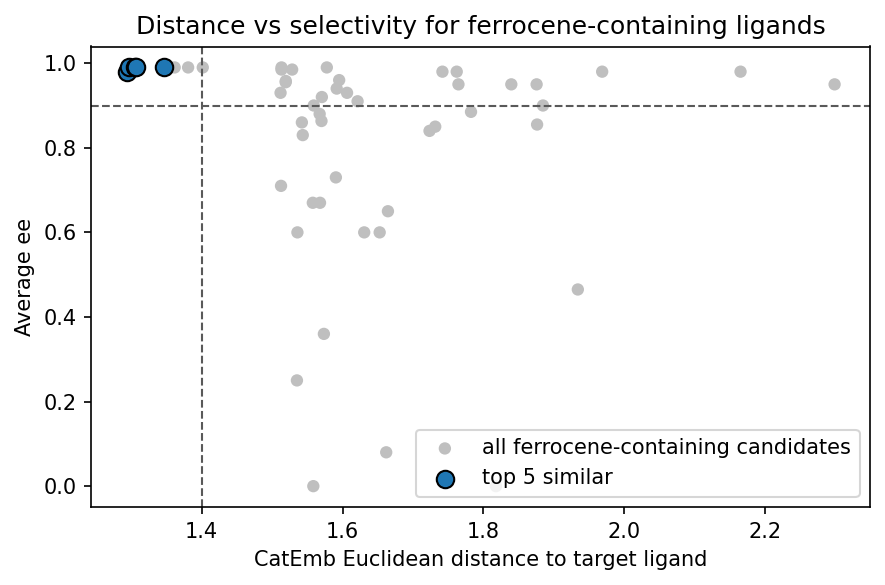

Outputs saved to: /inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/8359-xulicheng/CatEmb/GitHub/CatEmb/notebook/recommend_results/aho_single_p_to_ferrocene_showcase


In [6]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.scatter(ranked_df["euclidean_distance"], ranked_df["avg_ee"], s=35, color="0.75", edgecolor="none", label="all ferrocene-containing candidates")
ax.scatter(top5_df["euclidean_distance"], top5_df["avg_ee"], s=70, color="tab:blue", edgecolor="black", label="top 5 similar")
#ax.scatter(bottom5_df["euclidean_distance"], bottom5_df["avg_ee"], s=35, color="0.75", edgecolor="none", label="all Fe-containing candidates")
ax.axhline(HIGH_EE_THRESHOLD, color="0.35", ls="--", lw=1)
ax.axvline(1.4, color="0.35", ls="--", lw=1)
ax.set_xlabel("CatEmb Euclidean distance to target ligand")
ax.set_ylabel("Average ee")
ax.set_title("Distance vs selectivity for ferrocene-containing ligands")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "euclidean_distance_vs_fe_avg_ee_top5.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Outputs saved to: {OUTPUT_DIR}")
